In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import torch
import numpy as np

from quantem.core.visualization import show_2d
from quantem.tomography.utils import rot_ZXZ

# Creating Phantom Dataset
Cedric Lim, *12/5/2025*

**Note: Requires the tomography branch (TEMP)**

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

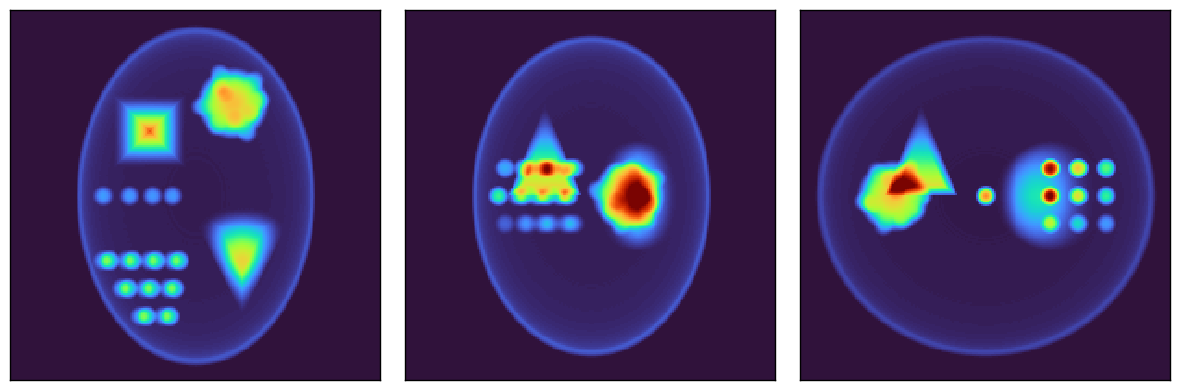

In [17]:
# Load phantom volume

phantom_vol = torch.from_numpy(np.load('../data/phantom.npy')).type(torch.float32)

show_2d(
    [phantom_vol.sum(axis = 0),
     phantom_vol.sum(axis = 1),
     phantom_vol.sum(axis = 2)],
    cmap = 'turbo',
    vmin = 0,
    vmax = 50
)


## Simulate tilt series dataset

Create a tilt series dataset with a tilt step of 2 degrees, tilt range of (-60, 60). with a 2 degree systematic tilt axis error

In [23]:
tilt_step = 2
tilt_angles = torch.arange(-60, 61, tilt_step).type(torch.float32)
tilt_series = []
tilt_axis = 2

for tilt_angle in tilt_angles:
    tilt_series.append(rot_ZXZ(phantom_vol.unsqueeze(0), z1 = tilt_axis, x = tilt_angle, z3 = -tilt_axis, device = 'cpu').squeeze(0).sum(axis = 0))

tilt_series = torch.stack(tilt_series)
print("Tilt series shape: ", tilt_series.shape)

/home/cedlim/quantem/quantem/src/quantem/tomography/utils.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=device)


Tilt series shape:  torch.Size([61, 200, 200])


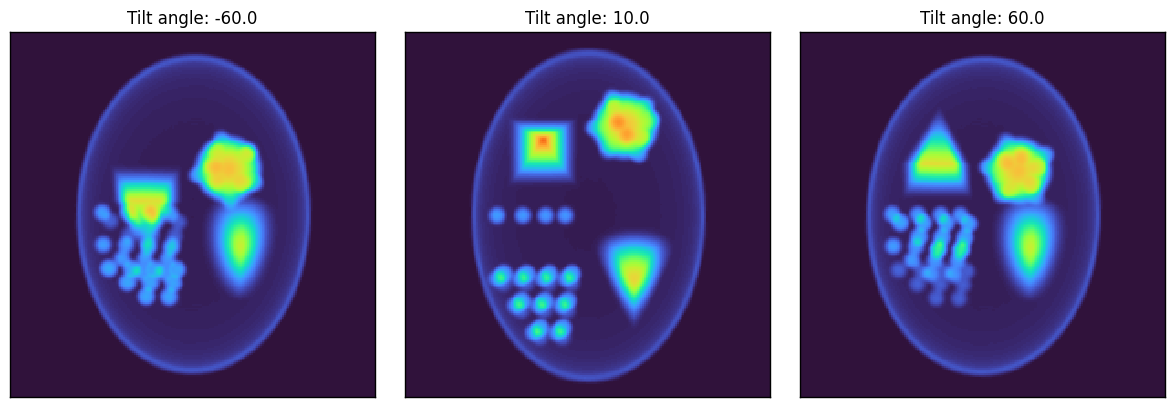

: 

In [ ]:
fig, ax = show_2d(
    [tilt_series[0], tilt_series[35], tilt_series[60]],
    titles = ['Tilt angle: {}'.format(tilt_angles[0]),
              'Tilt angle: {}'.format(tilt_angles[35]),
              'Tilt angle: {}'.format(tilt_angles[60])],
    cmap = 'turbo',
    vmin = 0,
    vmax = 50
)
